# 📊 So sánh Nhãn: Gốc (Original) vs OOF (External)
Notebook này phân tích chi tiết sự khác biệt giữa nhãn gốc do người gán (VietNamDataset) và nhãn tạo tự động/OOF (VietNamPotholeDataset_External) trên cùng một tập ảnh.

In [1]:
import os
import glob
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Config
DATASET_ORIG_PATH = "../data/VietNamDataset"
DATASET_OOF_PATH = "../data/processed/VietNamPotholeDataset_External"

def extract_base_id(filename):
    """Trích xuất ID gốc của ảnh, bỏ qua phần hậu tố sinh tự động của Roboflow"""
    basename = os.path.splitext(os.path.basename(filename))[0]
    if "_jpg" in basename:
        return basename.split("_jpg")[0]
    return basename

def get_labels_dict(base_path):
    labels_dict = {}
    for split in ['train', 'valid', 'test', 'full_dataset']:
        lbl_path = os.path.join(base_path, split, 'labels')
        img_path = os.path.join(base_path, split, 'images')
        
        if os.path.exists(lbl_path):
            for file in glob.glob(os.path.join(lbl_path, "*.txt")):
                basename = os.path.splitext(os.path.basename(file))[0]
                base_id = extract_base_id(basename)
                
                # Try to find corresponding image (using exact basename)
                img_file = os.path.join(img_path, basename + ".jpg")
                if not os.path.exists(img_file):
                    img_file = os.path.join(img_path, basename + ".png")
                
                labels_dict[base_id] = {
                    'label_path': file,
                    'img_path': img_file if os.path.exists(img_file) else None,
                    'basename': basename
                }
    return labels_dict

# Load dicts mapped by base_id
orig_dict = get_labels_dict(DATASET_ORIG_PATH)
oof_dict = get_labels_dict(DATASET_OOF_PATH)

# Find common keys (same base images)
common_ids = set(orig_dict.keys()).intersection(set(oof_dict.keys()))

print(f"Số lượng file nhãn tập Gốc (Original): {len(orig_dict)}")
print(f"Số lượng file nhãn tập OOF (External): {len(oof_dict)}")
print(f"Số lượng ảnh CHUNG (cùng ID) giữa 2 tập: {len(common_ids)}")

Số lượng file nhãn tập Gốc (Original): 500
Số lượng file nhãn tập OOF (External): 500
Số lượng ảnh CHUNG (cùng ID) giữa 2 tập: 496


### 1. Phân tích chi tiết số lượng và kích thước hộp (Bounding Boxes)

In [2]:
# Extract boxes for common images
orig_boxes = []
oof_boxes = []

for base_id in common_ids:
    # Original
    with open(orig_dict[base_id]['label_path'], "r") as f:
        for line in f.readlines():
            parts = line.strip().split()
            if len(parts) == 5:
                class_id, x_c, y_c, w, h = map(float, parts)
                orig_boxes.append({"img_id": base_id, "w": w, "h": h, "area": w*h, "source": "Original"})
                
    # OOF
    with open(oof_dict[base_id]['label_path'], "r") as f:
        for line in f.readlines():
            parts = line.strip().split()
            if len(parts) == 5:
                class_id, x_c, y_c, w, h = map(float, parts)
                oof_boxes.append({"img_id": base_id, "w": w, "h": h, "area": w*h, "source": "OOF"})

df_orig = pd.DataFrame(orig_boxes)
df_oof = pd.DataFrame(oof_boxes)

print(f"Tổng số Boxes (Original): {len(df_orig)}")
print(f"Tổng số Boxes (OOF): {len(df_oof)}")

# Nếu OOF nhiều box hơn -> Mô hình bắt được nhiều ổ gà nhỏ hơn, hoặc bị nhiễu (FP)
# Nếu OOF ít box hơn -> Mô hình bỏ sót, hoặc gộp các box gần nhau lại

Tổng số Boxes (Original): 1012
Tổng số Boxes (OOF): 1118


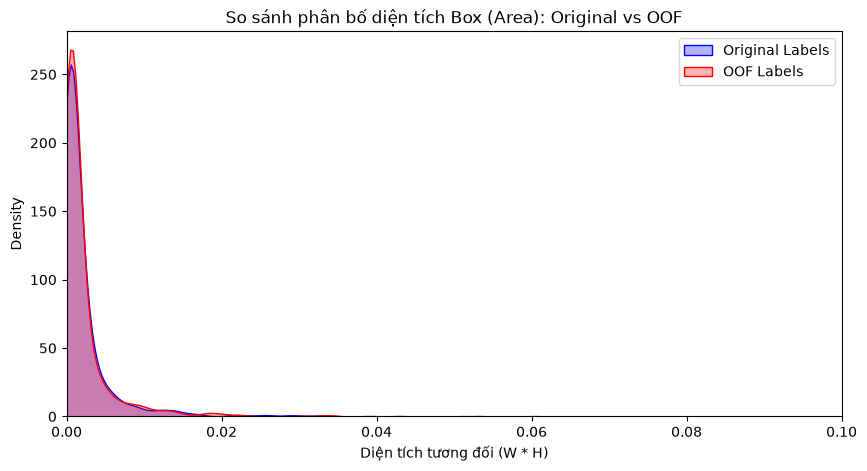

In [3]:
# Biểu đồ so sánh phân bố kích thước (Area)
plt.figure(figsize=(10, 5))
sns.kdeplot(df_orig['area'], label='Original Labels', color='blue', fill=True, alpha=0.3)
sns.kdeplot(df_oof['area'], label='OOF Labels', color='red', fill=True, alpha=0.3)
plt.title("So sánh phân bố diện tích Box (Area): Original vs OOF")
plt.xlabel("Diện tích tương đối (W * H)")
plt.xlim(0, 0.1) # Zoom vào các box nhỏ
plt.legend()
plt.show()

### 2. Trực quan hóa (Visualize) đối chiếu trực tiếp trên cùng 1 ảnh

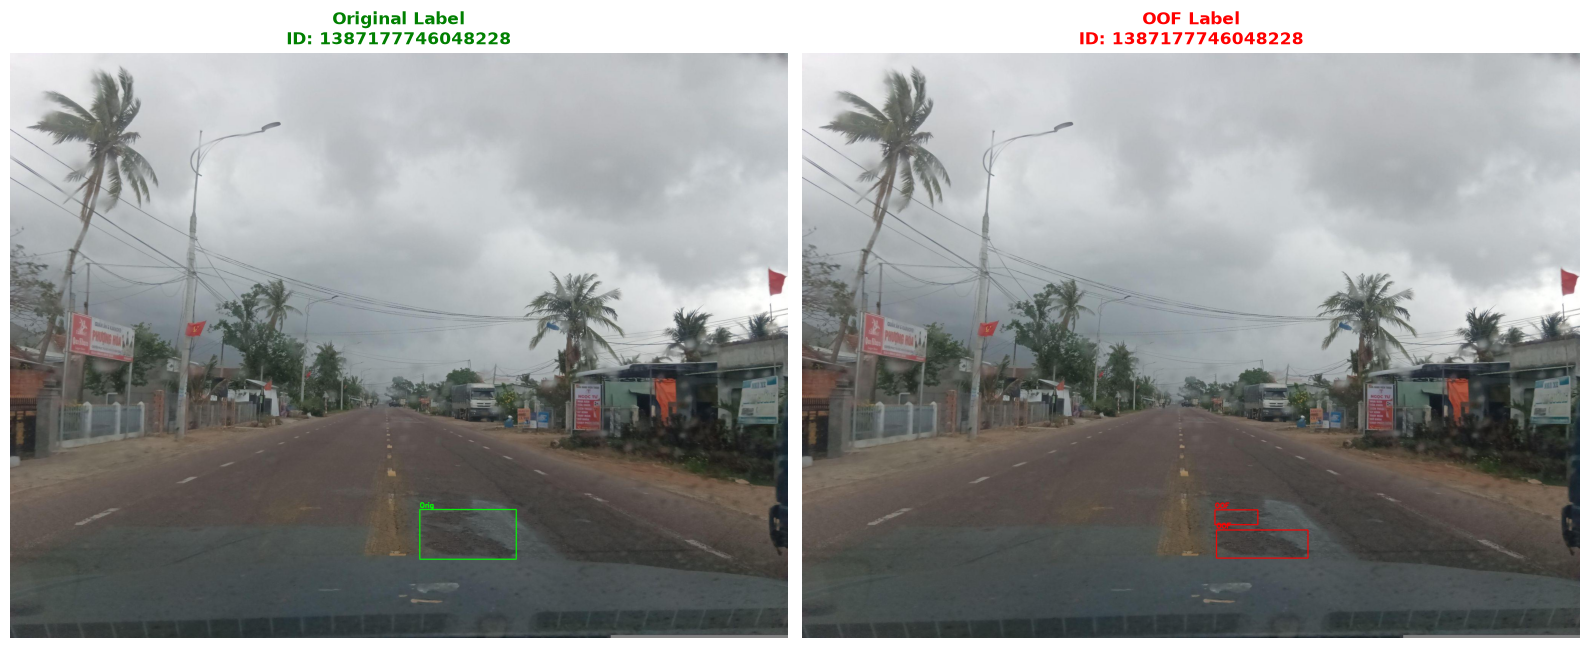

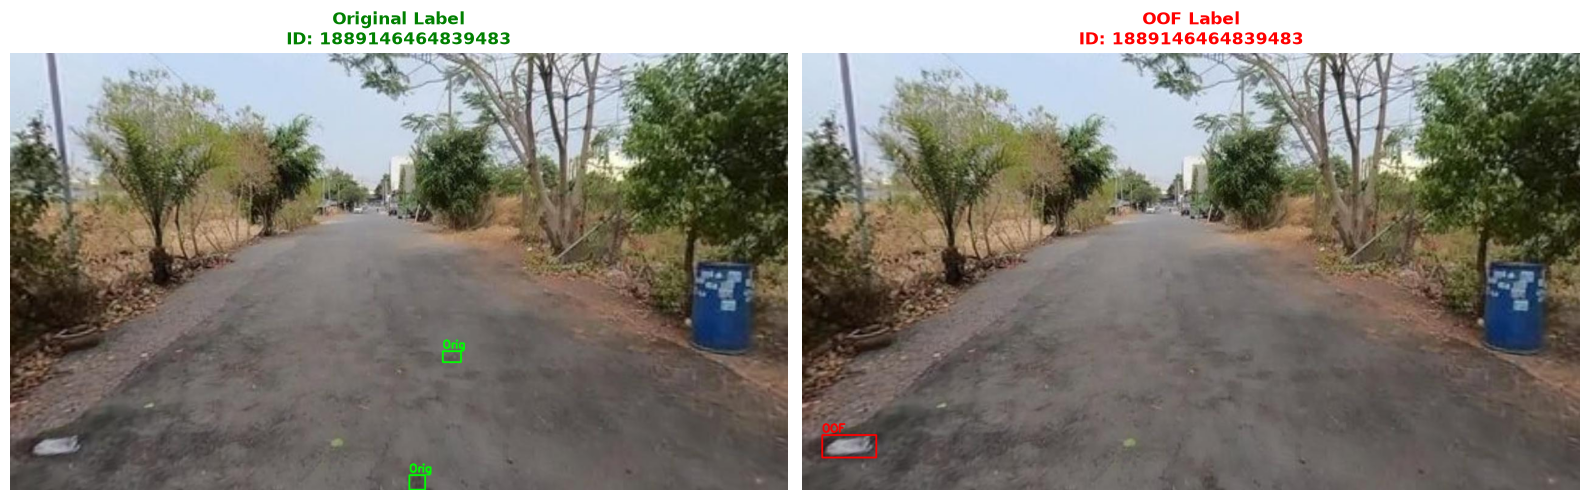

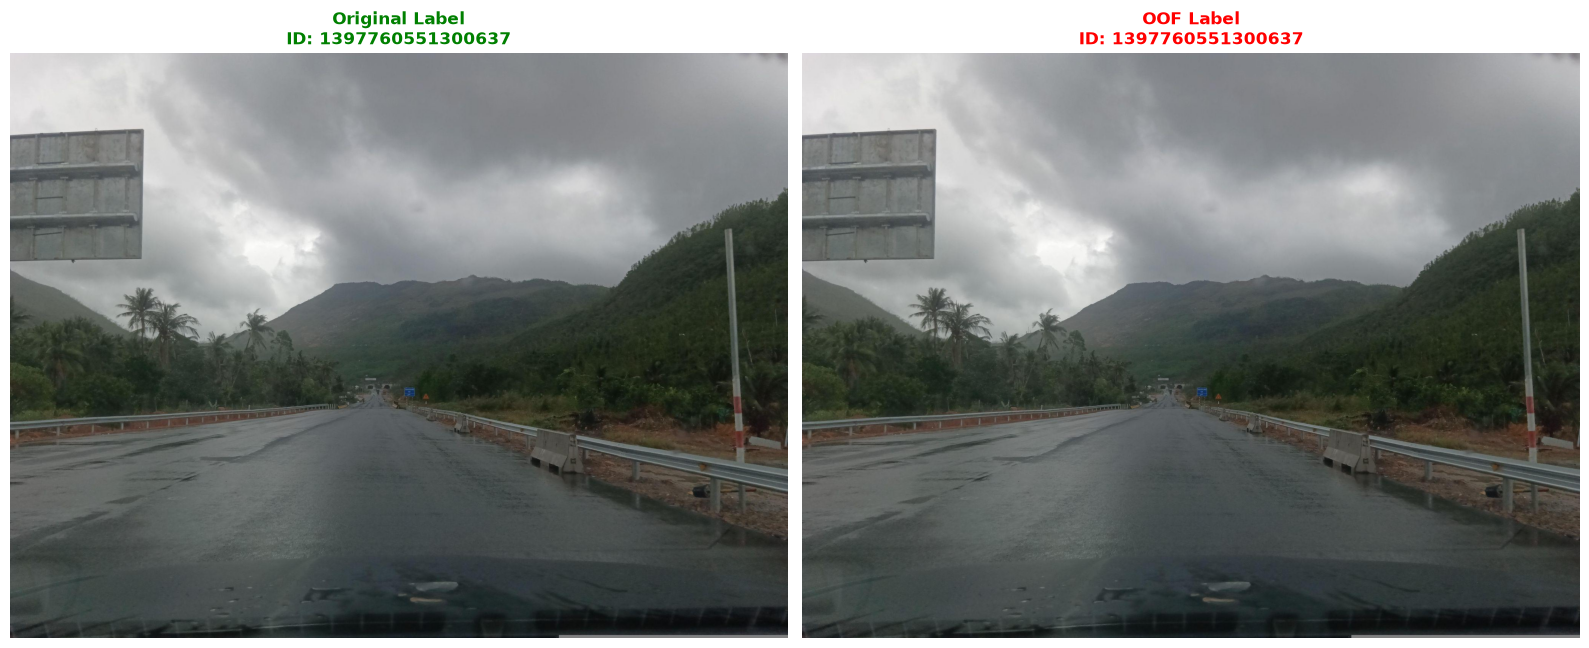

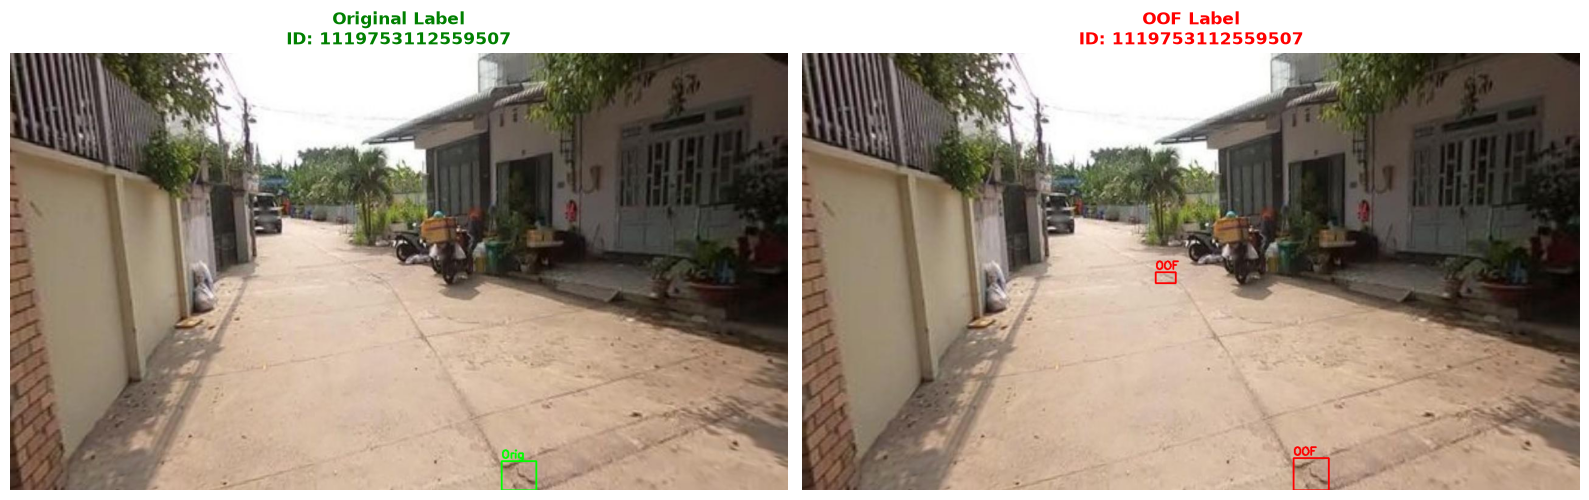

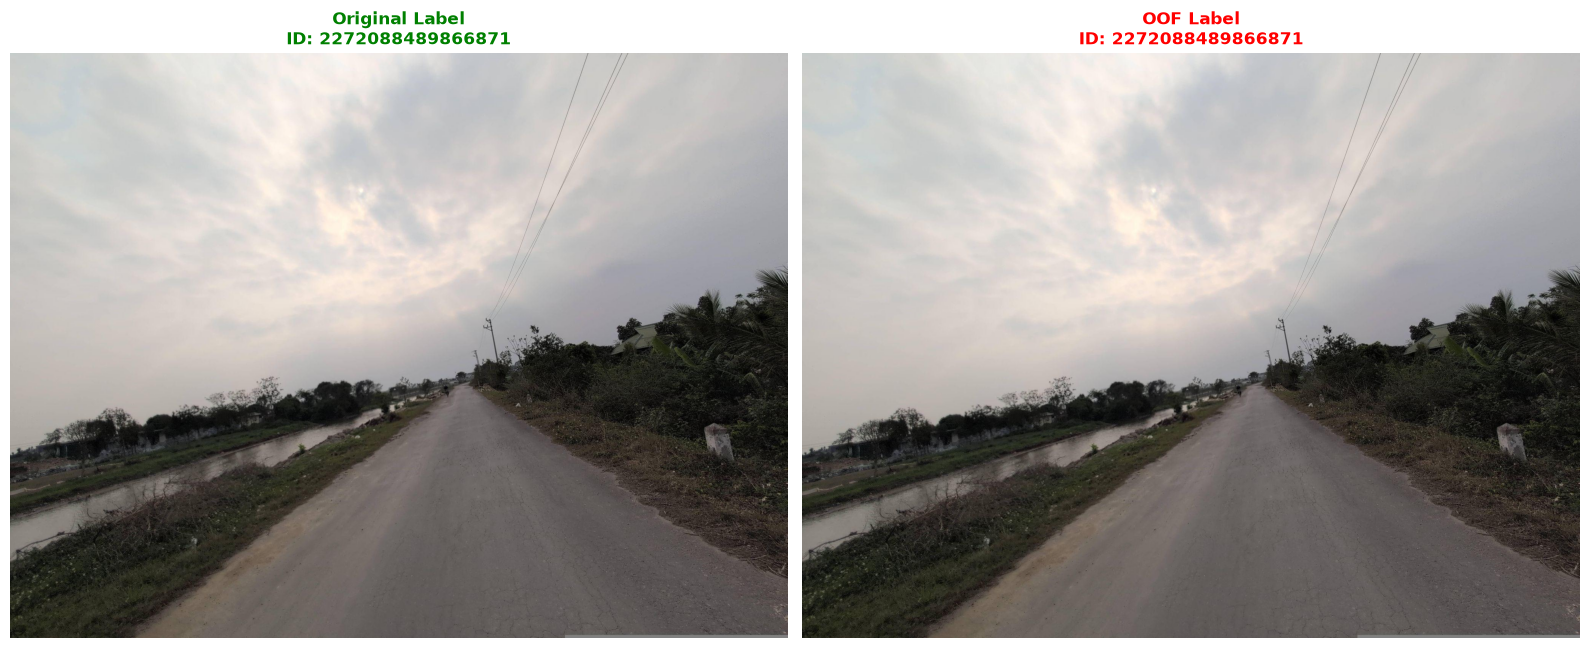

In [19]:
import random

# Lấy 5 ảnh ngẫu nhiên có chung ID
sample_ids = random.sample(list(common_ids), min(5, len(common_ids)))

for base_id in sample_ids:
    # Đọc ảnh gốc (có thể lấy từ orig_dict hoặc oof_dict đều được vì là cùng 1 ảnh)
    img_path = orig_dict[base_id]['img_path']
    if img_path is None: continue
        
    img_orig = cv2.imread(img_path)
    if img_orig is None: continue
    img_orig = cv2.cvtColor(img_orig, cv2.COLOR_BGR2RGB)
    
    img_oof = img_orig.copy()
    h_img, w_img, _ = img_orig.shape
    
    # Vẽ Original Labels (Xanh lá)
    with open(orig_dict[base_id]['label_path'], "r") as f:
        for line in f.readlines():
            parts = line.strip().split()
            if len(parts) == 5:
                _, x_c, y_c, w, h = map(float, parts)
                x1, y1 = int((x_c - w/2) * w_img), int((y_c - h/2) * h_img)
                x2, y2 = int((x_c + w/2) * w_img), int((y_c + h/2) * h_img)
                cv2.rectangle(img_orig, (x1, y1), (x2, y2), (0, 255, 0), 2)
                cv2.putText(img_orig, "Orig", (x1, y1-5), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)

    # Vẽ OOF Labels (Đỏ)
    with open(oof_dict[base_id]['label_path'], "r") as f:
        for line in f.readlines():
            parts = line.strip().split()
            if len(parts) == 5:
                _, x_c, y_c, w, h = map(float, parts)
                x1, y1 = int((x_c - w/2) * w_img), int((y_c - h/2) * h_img)
                x2, y2 = int((x_c + w/2) * w_img), int((y_c + h/2) * h_img)
                cv2.rectangle(img_oof, (x1, y1), (x2, y2), (255, 0, 0), 2)
                cv2.putText(img_oof, "OOF", (x1, y1-5), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 0, 0), 2)

    # Plot
    fig, axes = plt.subplots(1, 2, figsize=(16, 8))
    axes[0].imshow(img_orig)
    axes[0].set_title(f"Original Label\nID: {base_id}", color='green', fontweight='bold')
    axes[0].axis("off")
    
    axes[1].imshow(img_oof)
    axes[1].set_title(f"OOF Label\nID: {base_id}", color='red', fontweight='bold')
    axes[1].axis("off")
    
    plt.tight_layout()
    plt.show()

### 3. Phân bố ảnh theo Đường (Street) và theo Split (Train/Valid/Test)
Biểu đồ tròn thể hiện trong 500 tấm ảnh thuộc tập `VietNamDataset`, mỗi ảnh thuộc đường nào và nằm trong folder đầu vào nào.

**Ghi chú quan trọng về phân bố dữ liệu:** Dữ liệu được lựa chọn tập trung chủ yếu vào các tuyến đường chính và gom các đường nhỏ khác thành nhóm **"Đường hỗn hợp"**. Đây là tập dữ liệu mang tính chủ đích, thể hiện những đoạn đường đang thi công hoặc xuống cấp, có nhiều ổ gà mang tính **đặc trưng cho điều kiện giao thông và thị trường Việt Nam**, chứ không tập trung vào đường đất đá nông thôn.

In [ ]:
# ========================================================
# Biểu đồ tròn: Phân bố 500 ảnh theo Nhóm Đường và theo Split
# ========================================================
import os
import glob
import matplotlib.pyplot as plt
import numpy as np

DATASET_PATH = "../data/VietNamDataset"

def extract_base_id(filename):
    """Trích xuất ID gốc (bỏ hậu tố Roboflow)"""
    basename = os.path.splitext(os.path.basename(filename))[0]
    if "_jpg" in basename:
        return basename.split("_jpg")[0]
    return basename

# 1. Thu thập tên ảnh từ các folder gốc (đường/street)
EXCLUDE = {'train', 'valid', 'test', 'full_dataset'}
source_map = {}  # base_id -> street_folder_name

for item in sorted(os.listdir(DATASET_PATH)):
    full = os.path.join(DATASET_PATH, item)
    if os.path.isdir(full) and item not in EXCLUDE:
        for f in os.listdir(full):
            if f.lower().endswith(('.jpg', '.png', '.jpeg')):
                base_id = os.path.splitext(f)[0]
                source_map[base_id] = item

# 2. Mapping từng ảnh trong train/valid/test -> Nhóm đường gốc
per_split = {}  # split -> {group: count}
overall = {}    # group -> total_count

MAIN_STREETS = ['DinhCongTrangStreet', 'HoangHuuNamStreet', 'National_Highway_1']

for split in ['train', 'valid', 'test']:
    img_path = os.path.join(DATASET_PATH, split, 'images')
    if not os.path.exists(img_path):
        continue
    per_split[split] = {}
    for f in os.listdir(img_path):
        if not f.lower().endswith(('.jpg', '.png', '.jpeg')):
            continue
        base_id = extract_base_id(f)
        folder = source_map.get(base_id, 'Không xác định')
        
        # Phân loại vào nhóm chính hoặc "Đường hỗn hợp"
        if folder in MAIN_STREETS:
            group = folder
        else:
            group = 'Đường hỗn hợp'
            
        per_split[split][group] = per_split[split].get(group, 0) + 1
        overall[group] = overall.get(group, 0) + 1

total = sum(overall.values())
print(f"Tổng số ảnh trong train/valid/test: {total}\n")

# ===========================
# BIỂU ĐỒ TRÒN TỔNG THỂ
# ===========================

# Đổi tên hiển thị cho đẹp
DISPLAY_NAMES = {
    'DinhCongTrangStreet': 'Đinh Công Tráng',
    'HoangHuuNamStreet': 'Hoàng Hữu Nam',
    'National_Highway_1': 'Quốc lộ 1',
    'Đường hỗn hợp': 'Đường hỗn hợp'
}

labels_overall = []
sizes_overall = []
for group in sorted(overall.keys(), key=lambda x: overall[x], reverse=True):
    disp_name = DISPLAY_NAMES.get(group, group)
    labels_overall.append(f"{disp_name}\n({overall[group]})")
    sizes_overall.append(overall[group])

colors = plt.cm.Pastel1(np.linspace(0, 1, len(labels_overall)))

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# -- Pie chart tổng thể --
wedges, texts, autotexts = axes[0].pie(
    sizes_overall, labels=labels_overall, autopct='%1.1f%%',
    colors=colors, startangle=140, pctdistance=0.8,
    wedgeprops={'linewidth': 1.5, 'edgecolor': 'white'},
    textprops={'fontsize': 11, 'fontweight': 'bold'}
)
axes[0].set_title(
    f'Phân bố {total} ảnh theo Nhóm Đường (tổng thể)',
    fontsize=14, fontweight='bold', pad=20
)

# -- Stacked bar chart theo split --
split_names = ['train', 'valid', 'test']
unique_groups = sorted(overall.keys(), key=lambda x: overall[x], reverse=True)
x = np.arange(len(split_names))
bottom = np.zeros(len(split_names))

for idx, group in enumerate(unique_groups):
    vals = [per_split.get(s, {}).get(group, 0) for s in split_names]
    disp_name = DISPLAY_NAMES.get(group, group)
    axes[1].bar(x, vals, bottom=bottom, label=disp_name,
                color=colors[idx], edgecolor='white', linewidth=1)
    bottom += vals

axes[1].set_xticks(x)
axes[1].set_xticklabels([f'{s.upper()}\n({sum(per_split.get(s, {}).values())})' for s in split_names],
                         fontsize=12, fontweight='bold')
axes[1].set_ylabel('Số lượng ảnh', fontsize=12)
axes[1].set_title('Phân bố theo Split và Nhóm Đường', fontsize=14, fontweight='bold')
axes[1].legend(loc='upper right', fontsize=10, title='Nhóm Đường', title_fontsize=11)

# Thêm số liệu lên bar
for i, s in enumerate(split_names):
    total_split = sum(per_split.get(s, {}).values())
    axes[1].text(i, total_split + 5, str(total_split),
                ha='center', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.savefig('eda_outputs/pie_chart_street_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
